## Overview

In this mini-project you will implement a parameter study for a flow around an airfoil using OpenFOAM. You will need to write a python script that automatically generates the required meshes, runs the simulations, and post-processes the results. The final submission is a **research-style minipaper** of around **2-3 pages** (excluding figures) together with a **Git repository** containing code, project documentation, and all metadata needed to reproduce the results.

::: {.callout-important}
**Deadline (end of that date):** 05.07.2026

**Submission:** Via Moodle as repository link and PDF. Add us as members ([`@lambert.theisen`](https://gitlab.git.nrw/lambert.theisen) / [`@georgii.oblapenko`](https://gitlab.git.nrw/georgii.oblapenko)) to the project repository.
:::

::: {.callout-important}
**Software-engineering requirement.**
Treat this as a small research software project, not only as a report. Your work should live in a **Git repository** and be reproducible from the command line. Include code, and a short project documentation. Ideally, the result are two python files that can be run from the command line that will set up any necessary directories, set up the simulations, run them, and produce plots.

The first file performs a convergence study on the number of points used to represent the airfoil, the second file performs a parameter study of the impact of camber on the lift and drag coefficients.

A [Jupyter notebook with python code](https://rwth-acom.pages.git.nrw/teaching/mssd/exercises/02-openfoam.ipynb) is provided as a starting point.
The mesh generation is adapted from [curiosityFluidsAirfoilMesher.py](Code taken from https://github.com/curiosityFluids/curiosityFluidsAirfoilMesher/blob/master/curiosityFluidsAirfoilMesher.py) - an array of points is passed instead of a path to file containing the airfoil surface points.
:::

### Learning Outcomes

After completing this project, you should be able to:

- set up OpenFOAM and run basic testcases
- use various OpenFOAM utilities
- use Python scripts to automate workflows of executables that do not necessarily have a Python interface

### Specific tasks

Specifically, in this project, you will be studying the impact of airfoil camber on the lift and drag coefficients for a 0 angle of attack.
An example set up is provided further below, but it is for a fixed camber value and number of discretization points and does not produce any plots.
You are expected to

- For a single camber value, perform a convergence study with respect to the number of points used to discretize the surface, the script should produce a convergence plot
- Having obtained a reasonable number of points for the discretization, verify for how long a simulation should run in order to achieve convergence in the lift and drag coefficients as well as the residuals
- Now having a reasonable number of points for the discretization **and** a suitable simulation time, for a range of camber values, perform a parameter study of the impact of camber on the lift and drag coefficients, varying camber ("M") from 0 to 8. The report should have a plot of lift and drag coefficients as functions of the camber.

**Bonus task**: try running meshing on a highly-cambered airfoil with very few discretization points. Checkmesh should fail. Why is that? Inspect the mesh in ParaView. What is causing this behaviour?

## NACA Airfoils

NACA airfoils are a set of standardized parameterized airfoil shapes (with chord length 1). Most common are the 4-digit ones (i.e. NACA2412); for many specific profiles experimental and resolved CFD data is openly available.
This allows for solver validation/verification.
The 4 digits are MPTT, and correspond to

- M: maximum camber times 100
- P: location of maximum camber times 10
- TT: maximum thickness times 100

Symmetric airfoils have M=0 and P=0, and the thickness is given by the last two digits. The airfoil thickness is given as

$$
y_t = 5t \left[ 0.2969\sqrt{x} - 0.1260x - 0.3516x^2 + 0.2843x^3 - 0.1015x^4 \right],
$$

the mean camber line is computed as 

$$
y_c = 
    \begin{cases} 
        \frac{m}{p^2} \left(2px - x^2\right) & \text{for } 0 \leq x \leq p \\ 
        \frac{m}{(1-p)^2} \left((1-2p) + 2px - x^2\right) & \text{for } p \leq x \leq 1 
    \end{cases},
$$

its slope is therefore given by

$$
\frac{dy_c}{dx} = 
    \begin{cases} 
        \frac{2m}{p^2} \left(p - x\right) & \text{for } 0 \leq x \leq p \\ 
        \frac{2m}{(1-p)^2} \left(p - x\right) & \text{for } p \leq x \leq 1 
    \end{cases},
$$

and the coordinates of the upper ($U$) and lower ($L$) surfaces are

$$
\theta = \arctan\left(\frac{dy_c}{dx}\right),
$$

$$
x_U = x - y_t \sin\theta, \quad y_U = y_c + y_t \cos\theta,
$$
$$
x_L = x + y_t \sin\theta, \quad y_L = y_c - y_t \cos\theta.
$$

## Example setup using curiosityFluidsAirfoilMesher.py

Below, is an example python code that

- sets up a single directory for the case
- generates a discretized surface
- produces a mesh via curiosityFluidsAirfoilMesher.py
- creates necessary parameter files for use with OpenFOAM
- runs OpenFOAM

In [3]:
#| code-line-numbers: true
#| eval: false

import os
import numpy as np
from matplotlib import pyplot as plt
import math
from pathlib import Path
import subprocess
import pandas as pd

# set up directories
os.makedirs("openfoam_naca/constant", exist_ok=True)
os.makedirs("openfoam_naca/system", exist_ok=True)

# write empty file for use with paraview
with open("openfoam_naca/case.foam", "w") as f:
    f.write("")

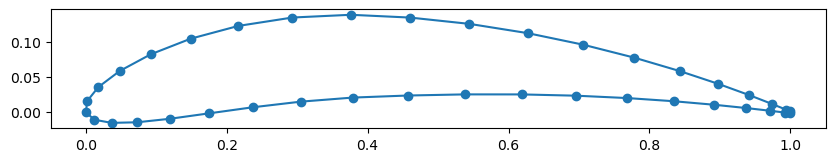

In [4]:
#| code-line-numbers: true
#| eval: false

# function to generate airfoil, plot it

def generate_naca4(digits, chord=1.0, points=100):
    """Generates 2D coordinates for a 4-digit NACA airfoil."""
    m = int(digits[0]) / 100.0  # Max camber
    p = int(digits[1]) / 10.0   # Position of max camber
    t = int(digits[2:]) / 100.0 # Max thickness

    # Use cosine spacing to cluster more points at the leading edge for a smoother curve
    beta = np.linspace(0, np.pi, points)
    x = (1 - np.cos(beta)) / 2

    # Thickness equation
    # (Note: -0.1015 leaves a tiny trailing edge gap, standard for NACA. 
    # Shapely will automatically close this gap when making the polygon).
    yt = 5 * t * (0.2969 * np.sqrt(x) - 0.1260 * x - 0.3516 * x**2 + 0.2843 * x**3 - 0.1015 * x**4)

    # Camber line calculations
    yc = np.zeros_like(x)
    dyc_dx = np.zeros_like(x)
    
    if p > 0:
        # Ahead of max camber
        front = x <= p
        yc[front] = (m / p**2) * (2 * p * x[front] - x[front]**2)
        dyc_dx[front] = (2 * m / p**2) * (p - x[front])
        
        # Behind max camber
        back = x > p
        yc[back] = (m / (1 - p)**2) * ((1 - 2 * p) + 2 * p * x[back] - x[back]**2)
        dyc_dx[back] = (2 * m / (1 - p)**2) * (p - x[back])

    theta = np.arctan(dyc_dx)

    # Upper surface coordinates
    xu = x - yt * np.sin(theta)
    yu = yc + yt * np.cos(theta)

    # Lower surface coordinates
    xl = x + yt * np.sin(theta)
    yl = yc - yt * np.cos(theta)

    # Combine into one continuous loop (Trailing Edge -> Leading Edge -> Trailing Edge)
    x_coords = np.concatenate([xu[::-1], xl[1:]])
    y_coords = np.concatenate([yu[::-1], yl[1:]])
    
    # Scale by chord length
    return np.column_stack((x_coords, y_coords)) * chord

airfoil_code = "8412"
chord_length = 1.0  # 1 meter long
n_surface_points = 20

discretized_surface_points = generate_naca4(airfoil_code, chord=chord_length, points=n_surface_points)

ax = plt.subplots(1, 1, figsize=(10, 5))[1]

ax.plot(discretized_surface_points[:, 0], discretized_surface_points[:, 1], 'o-', label=f'NACA {airfoil_code}')
ax.set_aspect("equal")
plt.show()

In [ ]:
print(discretized_surface_points.shape)

In [ ]:
#| echo: false

def curiosityFluidsAirfoilMesher(airfoil_points, path_to_blockdict="openfoam_naca/system/blockMeshDict"):
    # airfoil_points: [n_points, 2] array
    # path_to_blockdict: path to the blockMeshDict file

    #   This program is free software: you can redistribute it and/or modify
    #   it under the terms of the GNU General Public License as published by
    #   the Free Software Foundation, either version 3 of the License, or
    #   (at your option) any later version.

    #  This program is distributed in the hope that it will be useful,
    #   but WITHOUT ANY WARRANTY; without even the implied warranty of
    #   MERCHANTABILITY or FITNESS FOR A PARTICULAR PURPOSE.  See the
    #   GNU General Public License for more details.

    #   You should have received a copy of the GNU General Public License
    #   along with this program.  If not, see <https://www.gnu.org/licenses/>.
    #   Code taken from https://github.com/curiosityFluids/curiosityFluidsAirfoilMesher/blob/master/curiosityFluidsAirfoilMesher.py

    ChordLength=1
    DomainHeight=20  # Multiples Chord Length
    WakeLength=20 	 # Multiples Chord Length
    firstLayerHeight=0.001    # Multiples Chord Length
    growthRate=1.05				
    MaxCellSize=0.5	# Multiples of chordlength


    #These Values can be played with to improve mesh quality
    BLHeight=0.1    #Fraction of chord length - Height of BL block
    LeadingEdgeGrading=2
    TrailingEdgeGrading=0.8
    inletGradingFactor=0.5
    TrailingBlockAngle=5    	# Degrees



    NBL=int(np.rint(math.log(1-(BLHeight/firstLayerHeight*(1-growthRate)))/math.log(growthRate)))
    MaxLayerThickness=firstLayerHeight*growthRate**NBL
    BLGrading=MaxLayerThickness/firstLayerHeight
    LFF=(DomainHeight/2-BLHeight)
    NFF=int(np.rint(math.log(MaxCellSize/MaxLayerThickness)/math.log(1-MaxLayerThickness/LFF+MaxCellSize/LFF)))
    farfieldGrowthRate=(MaxCellSize/MaxLayerThickness)**(1/NFF)
    FFGrading=MaxCellSize/MaxLayerThickness
    NFFA=int(np.rint(3.14159/2*DomainHeight/2/MaxCellSize))


    # Import airfoil, split top and bottom, and split into quadrants


    X=airfoil_points[:,0] 								#X Coordinates
    Y=airfoil_points[:,1]								#Y Coordinates
    numpoint=X.size						#Number of points
    xTop=np.array([])							#Initialize Top half X Coordinates
    yTop=np.array([])							#Initialize Top half Y Coordinates
    xBottom=np.array([])						#Initialize Bottom half X Coordinates
    yBottom=np.array([])						#Initialize Bottom half Y Coordinates
    TopCount=0
    BottomCount=0
    for i in range(numpoint):
        if X[i]-X[i-1]<0 and i!=0 and i!=numpoint-1:
            xTop=np.append(xTop,X[i])
            yTop=np.append(yTop,Y[i])
            TopCount+=1
        elif X[i]-X[i-1]>0 and i!=0 and i!=numpoint-1:
            xBottom=np.append(xBottom,X[i])
            yBottom=np.append(yBottom,Y[i])
            BottomCount+=1
    # South West Quadrant of Airfoil
    SWx=xBottom[xBottom<0.25]
    SWy=yBottom[xBottom<0.25]
    LSW=0
    for i in range(len(SWx)-1):
        LSW=LSW+math.sqrt((SWx[i+1]-SWx[i])**2+(SWy[i+1]-SWy[i])**2)
    rSW=LeadingEdgeGrading**(1/NFFA)
    if LeadingEdgeGrading!=1:
        dx2SW=LeadingEdgeGrading*LSW*((1-rSW**NFFA)/(1-rSW))**(-1)
    else:
        dx2SW=LSW/NFFA

    # North West Quadrant of Airfoil
    NWx=xTop[xTop<0.25]
    NWy=yTop[xTop<0.25]
    LNW=0
    for i in range(len(NWx)-1):
        LNW=LNW+math.sqrt((NWx[i+1]-NWx[i])**2+(NWy[i+1]-NWy[i])**2)
    rNW=LeadingEdgeGrading**(1/NFFA)
    if LeadingEdgeGrading!=1:
        dx2=LeadingEdgeGrading*LNW*((1-rNW**NFFA)/(1-rNW))**(-1)
    else:
        dx2=LNW/NFFA

    # North East Quadrant of Airfoil
    NEx=xTop[xTop>0.25]
    NEy=yTop[xTop>0.25]
    LNE=0
    for i in range(len(NEx)-1):
        LNE=LNE+math.sqrt((NEx[i+1]-NEx[i])**2+(NEy[i+1]-NEy[i])**2)
    NNE=int(np.rint(math.log(TrailingEdgeGrading)/math.log(1-dx2*(1/LNE-TrailingEdgeGrading/LNE))))
    dxNET=TrailingEdgeGrading*dx2
    # South East Quadrant of Airfoil
    SEx=xBottom[xBottom>0.25]
    SEy=yBottom[xBottom>0.25]
    LSE=0
    for i in range(len(SEx)-1):
        LSE=LSE+math.sqrt((SEx[i+1]-SEx[i])**2+(SEy[i+1]-SEy[i])**2)
    NSE=int(np.rint(math.log(TrailingEdgeGrading)/math.log(1-dx2SW*(1/LSE-TrailingEdgeGrading/LSE))))
    dxSET=TrailingEdgeGrading*dx2SW

    NWake=int(np.rint(math.log(MaxCellSize/dxSET)/math.log(1-dxSET/WakeLength+MaxCellSize/WakeLength)))
    WakeGrading=MaxCellSize/dxSET
    # Calculates Normal vectors of the airfoil for extrusion of boundary layer
    nxTop=np.zeros(TopCount)
    nyTop=np.zeros(TopCount)
    for i in range(TopCount):
        if i==0:
            nyTop[i]=-(xTop[i+1]-xTop[i])/((xTop[i+1]-xTop[i])**2+(yTop[i+1]-yTop[i])**2)**0.5
            nxTop[i]=(yTop[i+1]-yTop[i])/((xTop[i+1]-xTop[i])**2+(yTop[i+1]-yTop[i])**2)**0.5
        elif i==TopCount-1:
            nyTop[i]=-(xTop[i]-xTop[i-1])/((xTop[i]-xTop[i-1])**2+(yTop[i]-yTop[i-1])**2)**0.5
            nxTop[i]=(yTop[i]-yTop[i-1])/((xTop[i]-xTop[i-1])**2+(yTop[i]-yTop[i-1])**2)**0.5
        else:
            nyTop[i]=-(xTop[i+1]-xTop[i-1])/((xTop[i+1]-xTop[i-1])**2+(yTop[i+1]-yTop[i-1])**2)**0.5
            nxTop[i]=(yTop[i+1]-yTop[i-1])/((xTop[i+1]-xTop[i-1])**2+(yTop[i+1]-yTop[i-1])**2)**0.5
    nxBottom=np.zeros(BottomCount)
    nyBottom=np.zeros(BottomCount)
    for i in range(BottomCount):
        if i==0:
            nyBottom[i]=-(xBottom[i+1]-xBottom[i])/((xBottom[i+1]-xBottom[i])**2+(yBottom[i+1]-yBottom[i])**2)**0.5
            nxBottom[i]=(yBottom[i+1]-yBottom[i])/((xBottom[i+1]-xBottom[i])**2+(yBottom[i+1]-yBottom[i])**2)**0.5
        elif i==BottomCount-1:
            nyBottom[i]=-(xBottom[i]-xBottom[i-1])/((xBottom[i]-xBottom[i-1])**2+(yBottom[i]-yBottom[i-1])**2)**0.5
            nxBottom[i]=(yBottom[i]-yBottom[i-1])/((xBottom[i]-xBottom[i-1])**2+(yBottom[i]-yBottom[i-1])**2)**0.5
        else:
            nyBottom[i]=-(xBottom[i+1]-xBottom[i-1])/((xBottom[i+1]-xBottom[i-1])**2+(yBottom[i+1]-yBottom[i-1])**2)**0.5
            nxBottom[i]=(yBottom[i+1]-yBottom[i-1])/((xBottom[i+1]-xBottom[i-1])**2+(yBottom[i+1]-yBottom[i-1])**2)**0.5


    #Tail Point and tail normal for kutta condition wake angle
    XT=(X[1]+X[numpoint-2])/2
    YT=(Y[1]+Y[numpoint-2])/2
    nxT=-(0-YT)/((1-XT)**2+(0-YT)**2)**(0.5)
    nyT=(1-XT)/((1-XT)**2+(0-YT)**2)**(0.5)
    thetawake=math.atan(nxT/nyT)

    InletGrading=LeadingEdgeGrading*DomainHeight/inletGradingFactor
    rInletGrading=InletGrading**(1/NFFA)
    dxInletGrading=(3.14159*DomainHeight/4)*((1-rInletGrading**NFFA)/(1-rInletGrading))**(-1)
    Ltop=1+math.tan(TrailingBlockAngle*3.14159/180)*DomainHeight/2


    Px=np.zeros(19)
    Py=np.zeros(19)
    Px[0]=0
    Py[0]=0
    Px[1]=1+WakeLength
    Py[1]=-DomainHeight/2
    Px[2]=1+math.tan(TrailingBlockAngle*3.14159/180)*DomainHeight/2 
    Py[2]=-DomainHeight/2
    Px[3]=0
    Py[3]=-DomainHeight/2
    Px[4]=-DomainHeight/2
    Py[4]=0
    Px[5]=0
    Py[5]=DomainHeight/2
    Px[6]=1+math.tan(TrailingBlockAngle*3.14159/180)*DomainHeight/2
    Py[6]=DomainHeight/2
    Px[7]=1+WakeLength
    Py[7]=DomainHeight/2
    Px[9]=1+WakeLength
    Py[9]=0-math.tan(thetawake)*WakeLength
    Px[8]=1+WakeLength
    Py[8]=Py[9]+BLHeight
    Px[10]=1+WakeLength
    Py[10]=Py[9]-BLHeight
    Px[12]=1
    Py[12]=0
    Px[11]=1+BLHeight*(yTop[1]-yTop[0])/((xTop[1]-xTop[0])**2+(yTop[1]-yTop[0])**2)**0.5
    Py[11]=0-BLHeight*(xTop[1]-xTop[0])/((xTop[1]-xTop[0])**2+(yTop[1]-yTop[0])**2)**0.5
    Px[13]=1+BLHeight*(yBottom[BottomCount-1]-yBottom[BottomCount-2])/((xBottom[BottomCount-1]-xBottom[BottomCount-2])**2+(yBottom[BottomCount-1]-yBottom[BottomCount-2])**2)**0.5
    Py[13]=0-BLHeight*(xBottom[BottomCount-1]-xBottom[BottomCount-2])/((xBottom[BottomCount-1]-xBottom[BottomCount-2])**2+(yBottom[BottomCount-1]-yBottom[BottomCount-2])**2)**0.5
    Px[15]=0.25
    Py[15]=np.interp(0.25,xTop[::-1],yTop[::-1])    #[::-1] reverses list so that list is monotonically increasing with X
    ny15=(0.001)/((0.001)**2+(np.interp(0.251,xTop[::-1],yTop[::-1])-np.interp(0.25,xTop[::-1],yTop[::-1]))**2)**0.5
    nx15=-(np.interp(0.251,xTop[::-1],yTop[::-1])-np.interp(0.25,xTop[::-1],yTop[::-1]))/((0.001)**2+(np.interp(0.251,xTop[::-1],yTop[::-1])-np.interp(0.25,xTop[::-1],yTop[::-1]))**2)**0.5
    Px[14]=0.25+nx15*BLHeight
    Py[14]=Py[15]+ny15*BLHeight
    Px[16]=0.25
    Py[16]=np.interp(0.25,xBottom,yBottom)
    ny17=(0.001)/((0.001)**2+(np.interp(0.251,xBottom[::-1],yBottom[::-1])-np.interp(0.25,xBottom[::-1],yBottom[::-1]))**2)**0.5
    nx17=-(np.interp(0.251,xBottom[::-1],yBottom[::-1])-np.interp(0.25,xBottom[::-1],yBottom[::-1]))/((0.001)**2+(np.interp(0.251,xBottom[::-1],yBottom[::-1])-np.interp(0.25,xBottom[::-1],yBottom[::-1]))**2)**0.5
    Px[17]=0.25-nx15*BLHeight
    Py[17]=Py[16]-ny15*BLHeight
    Px[18]=-BLHeight
    Py[18]=0


    # Defines Control Points for meshing
    CPx=np.zeros(2)
    CPy=np.zeros(2)
    CPx[0]=-DomainHeight/2*math.cos(3.14159/4)
    CPy[0]=DomainHeight/2*math.sin(3.14159/4)
    CPx[1]=-DomainHeight/2*math.cos(3.14159/4)
    CPy[1]=-DomainHeight/2*math.sin(3.14159/4)


    NWCPx=np.zeros(len(NWx))
    NWCPy=np.zeros(len(NWx))
    for i in range(len(NWx)):
        NWCPx[i]=NWx[i]+np.interp(NWx[i],xTop[::-1],nxTop[::-1])*BLHeight
        NWCPy[i]=NWy[i]+np.interp(NWx[i],xTop[::-1],nyTop[::-1])*BLHeight
    LNWBL=0
    for i in range(len(NWx)-1):
        LNWBL+=((NWCPx[i+1]-NWCPx[i])**2+(NWCPy[i+1]-NWCPy[i])**2)**0.5


    SWCPx=np.zeros(len(SWx))
    SWCPy=np.zeros(len(SWx))
    for i in range(len(SWx)):
        SWCPx[i]=SWx[i]+np.interp(SWx[i],xBottom,nxBottom)*BLHeight
        SWCPy[i]=SWy[i]+np.interp(SWx[i],xBottom,nyBottom)*BLHeight
    LSWBL=0
    for i in range(len(SWx)-1):
        LSWBL+=((SWCPx[i+1]-SWCPx[i])**2+(SWCPy[i+1]-SWCPy[i])**2)**0.5

    NECPx=np.zeros(len(NEx))
    NECPy=np.zeros(len(NEx))
    for i in range(len(NEx)):
        NECPx[i]=NEx[i]+np.interp(NEx[i],xTop[::-1],nxTop[::-1])*BLHeight
        NECPy[i]=NEy[i]+np.interp(NEx[i],xTop[::-1],nyTop[::-1])*BLHeight
    LNEBL=0
    for i in range(len(NEx)-1):
        LNEBL+=((NECPx[i+1]-NECPx[i])**2+(NECPy[i+1]-NECPy[i])**2)**0.5
    rNWBL=LeadingEdgeGrading**(1/NFFA)
    if LeadingEdgeGrading!=1:
        dxNEBL=(LNWBL)*((1-rNWBL**NFFA)/(1-rNWBL))**(-1)
    else:
        dxNEBL=LNWBL/NFFA


    SECPx=np.zeros(len(SEx))
    SECPy=np.zeros(len(SEx))
    for i in range(len(SEx)):
        SECPx[i]=SEx[i]+np.interp(SEx[i],xBottom,nxBottom)*BLHeight
        SECPy[i]=SEy[i]+np.interp(SEx[i],xBottom,nyBottom)*BLHeight
    LSEBL=0
    for i in range(len(SEx)-1):
        LSEBL+=((SECPx[i+1]-SECPx[i])**2+(SECPy[i+1]-SECPy[i])**2)**0.5
    rSWBL=LeadingEdgeGrading**(1/NFFA)
    if LeadingEdgeGrading!=1:
        dxSEBL=(LSWBL)*((1-rSWBL**NFFA)/(1-rSWBL))**(-1)
    else:
        dxSEBL=LSWBL/NFFA

    #Calculations of gradings and cell-sizes

    e=100
    rR=1.5
    dr=0.00001
    while e>0.0000001:
        rRold=rR
        fR=dxInletGrading*(1-rR**NNE)/(1-rR)-Ltop
        ru=rR+dr
        rl=rR-dr
        fu=dxInletGrading*(1-ru**NNE)/(1-ru)-Ltop
        fl=dxInletGrading*(1-rl**NNE)/(1-rl)-Ltop
        dfdr=(fu-fl)/(2*dr)
        rR=rRold-fR/dfdr
        e=np.abs(rR-rRold)
    topGrading=rR**NNE
    BottomGrading=topGrading

    SmallCellTop=dxInletGrading*topGrading
    LTopWake=WakeLength-math.tan(thetawake)*DomainHeight/2

    e=100
    rR=1.5
    dr=0.00001
    while e>0.0000001:
        rRold=rR
        fR=SmallCellTop*(1-rR**NWake)/(1-rR)-LTopWake
        ru=rR+dr
        rl=rR-dr
        fu=SmallCellTop*(1-ru**NWake)/(1-ru)-LTopWake
        fl=SmallCellTop*(1-rl**NWake)/(1-rl)-LTopWake
        dfdr=(fu-fl)/(2*dr)
        rR=rRold-fR/dfdr
        e=np.abs(rR-rRold)
    TopWakeGrading=rR**NWake
    e=100
    rR=1.5
    dr=0.00001
    while e>0.0000001:
        rRold=rR
        fR=dxNEBL*(1-rR**NNE)/(1-rR)-LNEBL
        ru=rR+dr
        rl=rR-dr
        fu=dxNEBL*(1-ru**NNE)/(1-ru)-LNEBL
        fl=dxNEBL*(1-rl**NNE)/(1-rl)-LNEBL
        dfdr=(fu-fl)/(2*dr)
        rR=rRold-fR/dfdr
        e=np.abs(rR-rRold)

    NEBLEGrading=rR**NNE
    e=100
    rR=1.5
    dr=0.00001
    while e>0.0000001:
        rRold=rR
        fR=dxSEBL*(1-rR**NSE)/(1-rR)-LSEBL
        ru=rR+dr
        rl=rR-dr
        fu=dxSEBL*(1-ru**NSE)/(1-ru)-LSEBL
        fl=dxSEBL*(1-rl**NSE)/(1-rl)-LSEBL
        dfdr=(fu-fl)/(2*dr)
        rR=rRold-fR/dfdr
        e=np.abs(rR-rRold)
    SEBLEGrading=rR**NSE

    L14_5=math.sqrt((Px[14]-Px[5])**2+(Py[14]-Py[5])**2)
    e=100
    rR=1.5
    dr=0.00001
    while e>0.0000001:
        rRold=rR
        fR=MaxLayerThickness*(1-rR**NFF)/(1-rR)-L14_5
        ru=rR+dr
        rl=rR-dr
        fu=MaxLayerThickness*(1-ru**NFF)/(1-ru)-L14_5
        fl=MaxLayerThickness*(1-rl**NFF)/(1-rl)-L14_5
        dfdr=(fu-fl)/(2*dr)
        rR=rRold-fR/dfdr
        e=np.abs(rR-rRold)
    Grading14_5=(rR**NFF)

    L17_3=math.sqrt((Px[17]-Px[3])**2+(Py[17]-Py[3])**2)
    e=100
    rR=1.5
    dr=0.00001
    while e>0.0000001:
        rRold=rR
        fR=MaxLayerThickness*(1-rR**NFF)/(1-rR)-L17_3
        ru=rR+dr
        rl=rR-dr
        fu=MaxLayerThickness*(1-ru**NFF)/(1-ru)-L17_3
        fl=MaxLayerThickness*(1-rl**NFF)/(1-rl)-L17_3
        dfdr=(fu-fl)/(2*dr)
        rR=rRold-fR/dfdr
        e=np.abs(rR-rRold)
    Grading17_3=(rR**NFF)





    # Writes blockMeshDict file into system directory of current folder
    f = open(path_to_blockdict ,'w')
    f.write('/*--------------------------------*- C++ -*----------------------------------*\ \n')
    f.write('  =========                 | \n')
    f.write('  \\      /  F ield         | OpenFOAM: The Open Source CFD Toolbox \n')
    f.write('   \\    /   O peration     | Website:  https://openfoam.org \n')
    f.write('    \\  /    A nd           | Version:  6 \n')
    f.write('     \\/     M anipulation  | \n')
    f.write('\*---------------------------------------------------------------------------*/ \n')
    f.write('FoamFile \n')
    f.write('{ \n')
    f.write('    version     2.0; \n')
    f.write('    format      ascii; \n')
    f.write('    class       dictionary; \n')
    f.write('    object      blockMeshDict; \n')
    f.write('} \n')
    f.write('// * * * * * * * * * * * * * * * * * * * * * * * * * * * * * * * * * * * * * // \n')
    f.write('\n')
    f.write('convertToMeters '+str(ChordLength) +'; \n')
    f.write('\n')
    f.write('vertices\n')
    f.write('(\n')
    for i in range(19):
        linestring='    ('+str(Px[i])+' '+str(Py[i])+' 0)\n'
        f.write(linestring)
    for i in range(19):
        linestring='    ('+str(Px[i])+' '+str(Py[i])+' 1)\n'
        f.write(linestring)
    f.write(');\n\n')
    f.write('blocks\n')
    f.write('(\n')
    f.write('    hex (2 1 10 13 21 20 29 32) ('+str(NWake)+' '+str(NFF)+' 1) simpleGrading ('+str(TopWakeGrading)+' '+str(WakeGrading)+' '+str(WakeGrading)+' '+str(TopWakeGrading)+' '+str(1/FFGrading)+' '+str(1/FFGrading)+' '+str(1/FFGrading)+' '+str(1/FFGrading)+' 1 1 1 1) \n')
    f.write('    hex (3 2 13 17 22 21 32 36) ('+str(NSE)+' '+str(NFF)+' 1) simpleGrading ('+str(BottomGrading)+' '+str(SEBLEGrading)+' '+str(SEBLEGrading)+' '+str(BottomGrading)+' '+str(1/Grading17_3)+' '+str(1/FFGrading)+' '+str(1/FFGrading)+' '+str(1/Grading17_3)+' 1 1 1 1) \n')
    f.write('    hex (4 3 17 18 23 22 36 37) ('+str(NFFA)+' '+str(NFF)+' 1) edgeGrading ('+str(1/(InletGrading))+' '+str(1/LeadingEdgeGrading)+' '+str(1/LeadingEdgeGrading)+' '+str(1/(InletGrading))+' '+str(1/FFGrading)+' '+str(1/Grading17_3)+' '+str(1/Grading17_3)+' '+str(1/FFGrading)+' 1 1 1 1) \n')
    f.write('    hex (4 18 14 5 23 37 33 24) ('+str(NFF)+' '+str(NFFA)+' 1) edgeGrading ('+str(1/FFGrading)+' '+str(1/Grading14_5)+' '+str(1/Grading14_5)+' '+str(1/FFGrading)+' '+str(1/(InletGrading))+' '+str(1/LeadingEdgeGrading)+' '+str(1/LeadingEdgeGrading)+' '+str(1/(InletGrading))+' 1 1 1 1) \n')
    f.write('    hex (14 11 6 5 33 30 25 24) ('+str(NNE)+' '+str(NFF)+' 1) edgeGrading ('+str(NEBLEGrading)+' '+str(topGrading)+' '+str(topGrading)+' '+str(NEBLEGrading)+' '+str(Grading14_5)+' '+str(FFGrading)+' '+str(FFGrading)+' '+str(Grading14_5)+' 1 1 1 1) \n')
    f.write('    hex (11 8 7 6 30 27 26 25) ('+str(NWake)+' '+str(NFF)+' 1) simpleGrading ('+str(WakeGrading)+' '+str(TopWakeGrading)+' '+str(TopWakeGrading)+' '+str(WakeGrading)+' '+str(FFGrading)+' '+str(FFGrading)+' '+str(FFGrading)+' '+str(FFGrading)+' 1 1 1 1) \n')

    f.write('    hex (12 9 8 11 31 28 27 30) ('+str(NWake)+' '+str(NBL)+' 1) simpleGrading ('+str(WakeGrading)+' '+str(BLGrading)+' 1) \n')
    f.write('    hex (15 12 11 14 34 31 30 33) ('+str(NNE)+' '+str(NBL)+' 1) egeeGrading ('+str(TrailingEdgeGrading)+' '+str(NEBLEGrading)+' '+str(NEBLEGrading)+' '+str(TrailingEdgeGrading)+' '+str(BLGrading)+' '+str(BLGrading)+' '+str(BLGrading)+' '+str(BLGrading)+' 1 1 1 1) \n')
    f.write('    hex (0 15 14 18 19 34 33 37) ('+str(NFFA)+' '+str(NBL)+' 1) edgeGrading ('+str(LeadingEdgeGrading)+' '+str(1/LeadingEdgeGrading)+' '+str(1/LeadingEdgeGrading)+' '+str(LeadingEdgeGrading)+' '+str(BLGrading)+' '+str(BLGrading)+' '+str(BLGrading)+' '+str(BLGrading)+' 1 1 1 1) \n')
    f.write('    hex (18 17 16 0 37 36 35 19) ('+str(NFFA)+' '+str(NBL)+' 1) edgeGrading ('+str(1/LeadingEdgeGrading)+' '+str(LeadingEdgeGrading)+' '+str(LeadingEdgeGrading)+' '+str(1/LeadingEdgeGrading)+' '+str(1/BLGrading)+' '+str(1/BLGrading)+' '+str(1/BLGrading)+' '+str(1/BLGrading)+' 1 1 1 1) \n')
    f.write('    hex (17 13 12 16 36 32 31 35) ('+str(NSE)+' '+str(NBL)+' 1) edgeGrading ('+str(SEBLEGrading)+' '+str(TrailingEdgeGrading)+' '+str(TrailingEdgeGrading)+' '+str(SEBLEGrading)+' '+str(1/BLGrading)+' '+str(1/BLGrading)+' '+str(1/BLGrading)+' '+str(1/BLGrading)+' 1 1 1 1) \n')
    f.write('    hex (13 10 9 12 32 29 28 31) ('+str(NWake)+' '+str(NBL)+' 1) simpleGrading ('+str(WakeGrading)+' '+str(1/BLGrading)+' 1) \n')
    f.write(');\n\n')
    f.write('edges\n')
    f.write('(\n')
    #################
    # DOMAIN POINTS #
    #################
    f.write('    polyLine 11 14\n')
    f.write('    (\n')
    for i in range(len(NEx)):
        f.write('        ('+str(NECPx[i])+' '+str(NECPy[i])+' 0)\n')
    f.write('    )\n')
    f.write('    polyLine 30 33\n')
    f.write('    (\n')
    for i in range(len(NEx)):
        f.write('        ('+str(NECPx[i])+' '+str(NECPy[i])+' 1)\n')
    f.write('    )\n')
    f.write('    polyLine 14 18\n')
    f.write('    (\n')
    for i in range(len(NWx)):
        f.write('        ('+str(NWCPx[i])+' '+str(NWCPy[i])+' 0)\n')
    f.write('    )\n')
    f.write('    polyLine 33 37\n')
    f.write('    (\n')
    for i in range(len(NWx)):
        f.write('        ('+str(NWCPx[i])+' '+str(NWCPy[i])+' 1)\n')
    f.write('    )\n')
    f.write('    polyLine 18 17\n')
    f.write('    (\n')
    for i in range(len(SWx)):
        f.write('        ('+str(SWCPx[i])+' '+str(SWCPy[i])+' 0)\n')
    f.write('    )\n')
    f.write('    polyLine 37 36\n')
    f.write('    (\n')
    for i in range(len(SWx)):
        f.write('        ('+str(SWCPx[i])+' '+str(SWCPy[i])+' 1)\n')
    f.write('    )\n')
    f.write('    polyLine 17 13\n')
    f.write('    (\n')
    for i in range(len(SEx)):
        f.write('        ('+str(SECPx[i])+' '+str(SECPy[i])+' 0)\n')
    f.write('    )\n')
    f.write('    polyLine 36 32\n')
    f.write('    (\n')
    for i in range(len(SEx)):
        f.write('        ('+str(SECPx[i])+' '+str(SECPy[i])+' 1)\n')
    f.write('    )\n')
    f.write('    spline 12 15\n')
    f.write('    (\n')
    for i in range(len(NEx)):
        f.write('        ('+str(NEx[i])+' '+str(NEy[i])+' 0)\n')
    f.write('    )\n')
    f.write('    spline 31 34\n')
    f.write('    (\n')
    for i in range(len(NEx)):
        f.write('        ('+str(NEx[i])+' '+str(NEy[i])+' 1)\n')
    f.write('    )\n')
    f.write('    arc 4 5 ('+str(CPx[0])+' '+str(CPy[0])+' 0)\n')
    f.write('    arc 3 4 ('+str(CPx[1])+' '+str(CPy[1])+' 0)\n')
    f.write('    arc 23 24 ('+str(CPx[0])+' '+str(CPy[0])+' 1)\n')
    f.write('    arc 22 23 ('+str(CPx[1])+' '+str(CPy[1])+' 1)\n')

    ################################
    # AIRFOIL INTERPOLATION POINTS #
    ################################
    f.write('    spline 15 0\n')
    f.write('    (\n')
    for i in range(len(NWx)):
        f.write('        ('+str(NWx[i])+' '+str(NWy[i])+' 0)\n')
    f.write('    )\n')
    f.write('    spline 34 19\n')
    f.write('    (\n')
    for i in range(len(NWx)):
        f.write('        ('+str(NWx[i])+' '+str(NWy[i])+' 1)\n')
    f.write('    )\n')
    f.write('    spline 0 16\n')
    f.write('    (\n')
    for i in range(len(SWx)):
        f.write('        ('+str(SWx[i])+' '+str(SWy[i])+' 0)\n')
    f.write('    )\n')
    f.write('    spline 19 35\n')
    f.write('    (\n')
    for i in range(len(SWx)):
        f.write('        ('+str(SWx[i])+' '+str(SWy[i])+' 1)\n')
    f.write('    )\n')
    f.write('    spline 16 12\n')
    f.write('    (\n')
    for i in range(len(SEx)):
        f.write('        ('+str(SEx[i])+' '+str(SEy[i])+' 0)\n')
    f.write('    )\n')
    f.write('    spline 35 31\n')
    f.write('    (\n')
    for i in range(len(SEx)):
        f.write('        ('+str(SEx[i])+' '+str(SEy[i])+' 1)\n')
    f.write('    )\n')
    f.write(');\n\n')

    f.write('boundary\n')
    f.write('(\n')
    f.write('    frontAndBack\n')
    f.write('    {\n')
    f.write('        type empty;\n')
    f.write('        faces\n')
    f.write('        (\n')
    f.write('          (1 2 13 10)\n')
    f.write('          (2 3 17 13)\n')
    f.write('          (3 4 18 17)\n')
    f.write('          (18 4 5 14)\n')
    f.write('          (11 14 5 6)\n')
    f.write('          (8 11 6 7)\n')
    f.write('          (9 12 11 8)\n')
    f.write('          (12 15 14 11)\n')
    f.write('          (0 18 14 15)\n')
    f.write('          (17 18 0 16)\n')
    f.write('          (13 17 16 12)\n')
    f.write('          (10 13 12 9)\n')
    f.write('          (21 20 29 32)\n')
    f.write('          (22 21 32 36)\n')
    f.write('          (23 22 36 37)\n')
    f.write('          (23 37 33 24)\n')
    f.write('          (33 30 25 24)\n')
    f.write('          (30 27 26 25)\n')
    f.write('          (31 28 27 30)\n')
    f.write('          (34 31 30 33)\n')
    f.write('          (37 19 34 33)\n')
    f.write('          (37 36 35 19)\n')
    f.write('          (36 32 31 35)\n')
    f.write('          (32 29 28 31)\n')
    f.write('         );\n')
    f.write('     }\n')
    f.write('    farfield\n')
    f.write('    {\n')
    f.write('        type patch;\n')
    f.write('        faces\n')
    f.write('        (\n')
    f.write('          (4 23 24 5)\n')
    f.write('          (5 24 25 6)\n')
    f.write('          (6 25 26 7)\n')
    f.write('          (27 8 7 26)\n')
    f.write('          (28 9 8 27)\n')
    f.write('          (29 10 9 28)\n')
    f.write('          (20 1 10 29)\n')
    f.write('          (21 2 1 20)\n')
    f.write('          (22 3 2 21)\n')
    f.write('          (23 4 3 22)\n')
    f.write('         );\n')
    f.write('     }\n')
    f.write('    airfoil\n')
    f.write('    {\n')
    f.write('        type wall;\n')
    f.write('        faces\n')
    f.write('        (\n')
    f.write('          (34 15 12 31)\n')
    f.write('          (19 0 15 34)\n')
    f.write('          (0 19 35 16)\n')
    f.write('          (16 35 31 12)\n')
    f.write('         );\n')
    f.write('     }\n')
    f.write(');\n')

    f.close()

In [ ]:
curiosityFluidsAirfoilMesher(discretized_surface_points)

In [ ]:
# set flow parameters

rho_freestream = 1.225
u_freestream = 30

In [ ]:
# first we need to create the controlDict file

def create_control_dict(case_dir, end_time=0.6, u_inf=30, rho_inf=1.225, z_length=1.0, write_interval=0.05):
    # end_time: for how long the simulation runs
    # u_inf: free-stream velocity
    # rho_inf: free-stream density
    # z_length: extrusion in z-direction
    # these are used to compute lift and drag coefficients

    system_dir = os.path.join(case_dir, "system")
    os.makedirs(system_dir, exist_ok=True)
    area = 1.0 * z_length
    
    # Note: Double curly braces {{ }} are used to escape them in the Python f-string
    content = f"""/*--------------------------------*- C++ -*----------------------------------*\\
  =========                 |
  \\\\      /  F ield         | OpenFOAM: The Open Source CFD Toolbox
   \\\\    /   O peration     | Website:  https://openfoam.org
    \\\\  /    A nd           | Version:  13
     \\\\/     M anipulation  |
\\*---------------------------------------------------------------------------*/
FoamFile
{{
    format      ascii;
    class       dictionary;
    location    "system";
    object      controlDict;
}}
// * * * * * * * * * * * * * * * * * * * * * * * * * * * * * * * * * * * * * //

application     foamRun;
solver          incompressibleFluid;

startFrom       startTime;
startTime       0;

stopAt          endTime;
endTime         {end_time};

deltaT          0.0005; // Set conservative for initialization stability

writeControl    runTime;
writeInterval   {write_interval};

purgeWrite      0;
writeFormat     ascii;
writePrecision  6;
writeCompression off;
timeFormat      general;
timePrecision   6;
runTimeModifiable true;

functions
{{
    computeLiftDrag
    {{
        type            forceCoeffs;       // Must be an unquoted word
        libs            ("libforces.so");  // Shared libraries CAN be a string list
        writeControl    timeStep;
        writeInterval   1;

        patches         (airfoil);         // Name of your boundary patch in patches/polyMesh
        p               p;                 // Pressure field name
        U               U;                 // Velocity field name
        
        // For incompressible flows (using foamRun with incompressibleFluid module)
        rho             rhoInf;            
        rhoInf          {rho_inf}; // reference density
        
        CofR            (0 0 0);           // Center of Rotation (for moment coefficients)
        
        // Direction vectors (Adjust these based on your coordinate system orientation!)
        liftDir         (0 1 0);           // If lift is pointing up the Y-axis
        dragDir         (1 0 0);           // If drag is pointing along the X-axis
        pitchAxis       (0 0 1);           // Pitch axis (Z-axis)
        
        // Reference values used to normalize forces into Cd and Cl
        magUInf         {u_inf};          // Freestream velocity magnitude
        lRef            1.0;               // Reference length (e.g., chord length of airfoil in meters)
        Aref            {area};            // Planform Area (Chord 1.0m * Span 0.1m)
    }}

    residuals
    {{
        type            residuals;
        libs            ("libutilityFunctionObjects.so");
        writeControl    timeStep;
        writeInterval   1;
        fields          (U p);
    }}
}}

// ************************************************************************* //
"""
    
    dict_path = os.path.join(system_dir, "controlDict")
    with open(dict_path, "w") as f:
        f.write(content)
        
    return dict_path

create_control_dict("openfoam_naca", rho_inf=rho_freestream, u_inf=u_freestream)

In [ ]:
# run meshing

OPENFOAM_IMAGE = "microfluidica/openfoam:13"
PROJECT_DIR = Path.cwd().resolve()
case_dir = PROJECT_DIR  / "openfoam_naca"

def foam_cmd(*args, workdir="/work"):
    return [
        "docker",
        "run",
        "--rm",
        "-v",
        f"{PROJECT_DIR}:/work",
        "-w",
        workdir,
        OPENFOAM_IMAGE,
        *args,
    ]

subprocess.run(foam_cmd("blockMesh", "-case", "openfoam_naca"))

In [ ]:
# check mesh
subprocess.run(foam_cmd("checkMesh", "-case", "openfoam_naca"))

In [ ]:
def create_momentum_transport_sa(case_dir):
    constant_dir = os.path.join(case_dir, "constant")
    os.makedirs(constant_dir, exist_ok=True)
    
    # Using double curly braces {{ }} to escape them inside the Python f-string
    content = f"""/*--------------------------------*- C++ -*----------------------------------*\\
  =========                 |
  \\\\      /  F ield         | OpenFOAM: The Open Source CFD Toolbox
   \\\\    /   O peration     | Website:  https://openfoam.org
    \\\\  /    A nd           | Version:  13
     \\\\/     M anipulation  |
\\*---------------------------------------------------------------------------*/
FoamFile
{{
    format      ascii;
    class       dictionary;
    location    "constant";
    object      momentumTransport;
}}
// * * * * * * * * * * * * * * * * * * * * * * * * * * * * * * * * * * * * * //

simulationType  RAS;

RAS
{{
    model           SpalartAllmaras;
    turbulence      on;
    printCoeffs     on;
}}

// ************************************************************************* //
"""
    
    dict_path = os.path.join(constant_dir, "momentumTransport")
    with open(dict_path, "w") as f:
        f.write(content)
        
    return dict_path

create_momentum_transport_sa("openfoam_naca")


In [ ]:
def generate_openfoam_fvschemes_fvsolution(case_dir, steady_state=True):
    """
    Generates fvSchemes and fvSolution files tailored for OpenFOAM 13's
    modular framework (incompressibleFluid) with the Spalart-Allmaras model.
    """
    system_dir = os.path.join(case_dir, "system")
    
    # Determine schemes based on time-dependence
    ddt_scheme = "steadyState" if steady_state else "Euler"
    
    # -------------------------------------------------------------
    # 1. Define fvSchemes Content
    # -------------------------------------------------------------
    fv_schemes = f"""/*--------------------------------*- C++ -*----------------------------------*\\
  =========                 |
  \\\\      /  F ield         | OpenFOAM: The Open Source CFD Toolbox
   \\\\    /   O peration     | Website:  https://openfoam.org
    \\\\  /    A nd           | Version:  13
     \\\\/     M anipulation  |
\\*---------------------------------------------------------------------------*/
FoamFile
{{
    version     2.0;
    format      ascii;
    class       dictionary;
    object      fvSchemes;
}}
// * * * * * * * * * * * * * * * * * * * * * * * * * * * * * * * * * * * * * //

ddtSchemes
{{
    default         {ddt_scheme};
}}

gradSchemes
{{
    default         Gauss linear;
    grad(U)         Gauss linear;
}}

divSchemes
{{
    default         none;
    div(phi,U)      Gauss linearUpwind grad(U);
    div(phi,nuTilda) Gauss upwind;
    div((nuEff*dev2(T(grad(U))))) Gauss linear;
}}

laplacianSchemes
{{
    default         Gauss linear corrected;
}}

interpolationSchemes
{{
    default         linear;
}}

snGradSchemes
{{
    default         corrected;
}}

wallDist
{{
    method          meshWave;
}}

// ************************************************************************* //
"""

    # -------------------------------------------------------------
    # 2. Define fvSolution Content
    # -------------------------------------------------------------
    n_outer_correctors = 1 if steady_state else 2
    
    # Relaxation factors are critical for numerical stability in steady-state runs
    relaxation_factors = """relaxationFactors
{
    fields
    {
        p               0.3;
    }
    equations
    {
        U               0.7;
        nuTilda         0.7;
    }
}""" if steady_state else ""

    fv_solution = f"""/*--------------------------------*- C++ -*----------------------------------*\\
  =========                 |
  \\\\      /  F ield         | OpenFOAM: The Open Source CFD Toolbox
   \\\\    /   O peration     | Website:  https://openfoam.org
    \\\\  /    A nd           | Version:  13
     \\\\/     M anipulation  |
\\*---------------------------------------------------------------------------*/
FoamFile
{{
    version     2.0;
    format      ascii;
    class       dictionary;
    object      fvSolution;
}}
// * * * * * * * * * * * * * * * * * * * * * * * * * * * * * * * * * * * * * //

solvers
{{
    p
    {{
        solver          GAMG;
        tolerance       1e-06;
        relTol          0.01;
        smoother        GaussSeidel;
    }}

    pFinal
    {{
        $p;
        tolerance       1e-06;
        relTol          0;
    }}

    "(U|nuTilda)"
    {{
        solver          PBiCGStab;
        preconditioner  DILU;
        tolerance       1e-05;
        relTol          0.1;
    }}

    "(U|nuTilda)Final"
    {{
        solver          PBiCGStab;
        preconditioner  DILU;
        tolerance       1e-05;
        relTol          0;
    }}
}}

PIMPLE
{{
    nOuterCorrectors {n_outer_correctors};
    nCorrectors     2;
    nNonOrthogonalCorrectors 0;
}}

{relaxation_factors}

// ************************************************************************* //
"""

    # Write files out to the system folder
    with open(os.path.join(system_dir, "fvSchemes"), "w") as f:
        f.write(fv_schemes)

    with open(os.path.join(system_dir, "fvSolution"), "w") as f:
        f.write(fv_solution)

generate_openfoam_fvschemes_fvsolution("openfoam_naca")

In [ ]:
def generate_physical_properties(case_dir, nu_value=1.5e-5):
    """
    Generates a physicalProperties file for incompressible flow.
    """
    constant_dir = os.path.join(case_dir, "constant")
    
    file_content = f"""/*--------------------------------*- C++ -*----------------------------------*\\
  =========                 |
  \\\\      /  F ield         | OpenFOAM: The Open Source CFD Toolbox
   \\\\    /   O peration     | Website:      https://openfoam.org
    \\\\  /    A nd           | Version:      13
     \\\\/     M anipulation  |
\\*---------------------------------------------------------------------------*/
FoamFile
{{
    format      ascii;
    class       dictionary;
    location    "constant";
    object      physicalProperties;
}}
// * * * * * * * * * * * * * * * * * * * * * * * * * * * * * * * * * * * * * //

viscosityModel  constant;

nu              [0 2 -1 0 0 0 0] {nu_value};

// ************************************************************************* //
"""
    
    file_path = os.path.join(constant_dir, "physicalProperties")
    with open(file_path, "w") as f:
        f.write(file_content)

generate_physical_properties("openfoam_naca", nu_value=1.5e-5)

In [ ]:
def generate_0_directory(case_dir, u_freestream, rho_freestream, nu=1.5e-5):
    """
    Generates initial and boundary condition field files in the 0/ directory 
    for an OpenFOAM 13 incompressible Spalart-Allmaras airfoil simulation.
    """
    zero_dir = os.path.join(case_dir, "0")
    os.makedirs(zero_dir, exist_ok=True)
    
    # --- Turbulence Math for Spalart-Allmaras Freestream values ---
    # Standard guideline: nuTilda_freestream is 3 to 5 times kinematic viscosity
    nu_tilda_freestream = 3.0 * nu
    
    # Calculate initial nut from nuTilda using the SA model formulation
    cv1 = 7.1
    chi = nu_tilda_freestream / nu
    fv1 = (chi**3) / (chi**3 + cv1**3)
    nut_freestream = nu_tilda_freestream * fv1
    
    print(f"[+] Physical Constants & Computed Freestream Targets:")
    print(f"    - Inflow Velocity: {u_freestream} m/s")
    print(f"    - Freestream Density: {rho_freestream} kg/m³ (Used for reference/forces)")
    print(f"    - Kinematic Viscosity (nu): {nu} m²/s")
    print(f"    - Freestream nuTilda: {nu_tilda_freestream:.2e} m²/s")
    print(f"    - Freestream nut: {nut_freestream:.2e} m²/s\n")

    # -------------------------------------------------------------
    # 1. Field: U (Velocity Field)
    # -------------------------------------------------------------
    # -------------------------------------------------------------
    # Velocity (U)
    # -------------------------------------------------------------
    u_content = f"""/*--------------------------------*- C++ -*----------------------------------*\\
  =========                 |
  \\\\      /  F ield         | OpenFOAM: The Open Source CFD Toolbox
   \\\\    /   O peration     | Website:  https://openfoam.org
    \\\\  /    A nd           | Version:  13
     \\\\/     M anipulation  |
\\*---------------------------------------------------------------------------*/
FoamFile
{{
    version     2.0;
    format      ascii;
    class       volVectorField;
    location    "0";
    object      U;
}}
// * * * * * * * * * * * * * * * * * * * * * * * * * * * * * * * * * * * * * //

dimensions      [0 1 -1 0 0 0 0];

internalField   uniform ({u_freestream} 0 0);

boundaryField
{{
    farfield
    {{
        type            freestream;
        freestreamValue uniform ({u_freestream} 0 0);
    }}

    airfoil
    {{
        type            noSlip;
    }}

    frontAndBack
    {{
        type            empty;
    }}
}}

// ************************************************************************* //
"""

    # -------------------------------------------------------------
    # Kinematic Pressure (p = P_physical / rho)
    # -------------------------------------------------------------
    p_content = f"""/*--------------------------------*- C++ -*----------------------------------*\\
  =========                 |
  \\\\      /  F ield         | OpenFOAM: The Open Source CFD Toolbox
   \\\\    /   O peration     | Website:  https://openfoam.org
    \\\\  /    A nd           | Version:  13
     \\\\/     M anipulation  |
\\*---------------------------------------------------------------------------*/
FoamFile
{{
    version     2.0;
    format      ascii;
    class       volScalarField;
    location    "0";
    object      p;
}}
// * * * * * * * * * * * * * * * * * * * * * * * * * * * * * * * * * * * * * //

dimensions      [0 2 -2 0 0 0 0];

internalField   uniform 0;

boundaryField
{{
    farfield
    {{
        type            freestreamPressure;
        freestreamValue uniform 0;
    }}

    airfoil
    {{
        type            zeroGradient;
    }}

    frontAndBack
    {{
        type            empty;
    }}
}}

// ************************************************************************* //
"""

    # -------------------------------------------------------------
    # Modified Turbulent Viscosity (nuTilda)
    # -------------------------------------------------------------
    nutilda_content = f"""/*--------------------------------*- C++ -*----------------------------------*\\
  =========                 |
  \\\\      /  F ield         | OpenFOAM: The Open Source CFD Toolbox
   \\\\    /   O peration     | Website:  https://openfoam.org
    \\\\  /    A nd           | Version:  13
     \\\\/     M anipulation  |
\\*---------------------------------------------------------------------------*/
FoamFile
{{
    version     2.0;
    format      ascii;
    class       volScalarField;
    location    "0";
    object      nuTilda;
}}
// * * * * * * * * * * * * * * * * * * * * * * * * * * * * * * * * * * * * * //

dimensions      [0 2 -1 0 0 0 0];

internalField   uniform {nu_tilda_freestream};

boundaryField
{{
    farfield
    {{
        type            freestream;
        freestreamValue uniform {nu_tilda_freestream};
    }}

    airfoil
    {{
        type            fixedValue;
        value           uniform 0;
    }}

    frontAndBack
    {{
        type            empty;
    }}
}}

// ************************************************************************* //
"""

    # -------------------------------------------------------------
    # Turbulent Kinematic Viscosity (nut)
    # -------------------------------------------------------------
    nut_content = f"""/*--------------------------------*- C++ -*----------------------------------*\\
  =========                 |
  \\\\      /  F ield         | OpenFOAM: The Open Source CFD Toolbox
   \\\\    /   O peration     | Website:  https://openfoam.org
    \\\\  /    A nd           | Version:  13
     \\\\/     M anipulation  |
\\*---------------------------------------------------------------------------*/
FoamFile
{{
    version     2.0;
    format      ascii;
    class       volScalarField;
    location    "0";
    object      nut;
}}
// * * * * * * * * * * * * * * * * * * * * * * * * * * * * * * * * * * * * * //

dimensions      [0 2 -1 0 0 0 0];

internalField   uniform {nut_freestream};

boundaryField
{{
    farfield
    {{
        type            calculated;
        value           uniform {nut_freestream};
    }}

    airfoil
    {{
        type            nutUSpaldingWallFunction;
        value           uniform 0;
    }}

    frontAndBack
    {{
        type            empty;
    }}
}}

// ************************************************************************* //
"""

    # Write files to disk
    fields = {"U": u_content, "p": p_content, "nuTilda": nutilda_content, "nut": nut_content}
    for field_name, script_content in fields.items():
        file_path = os.path.join(zero_dir, field_name)
        with open(file_path, "w") as f:
            f.write(script_content)

generate_0_directory("openfoam_naca", u_freestream, rho_freestream)

In [ ]:
subprocess.run(foam_cmd("foamRun", "-case", "openfoam_naca"))

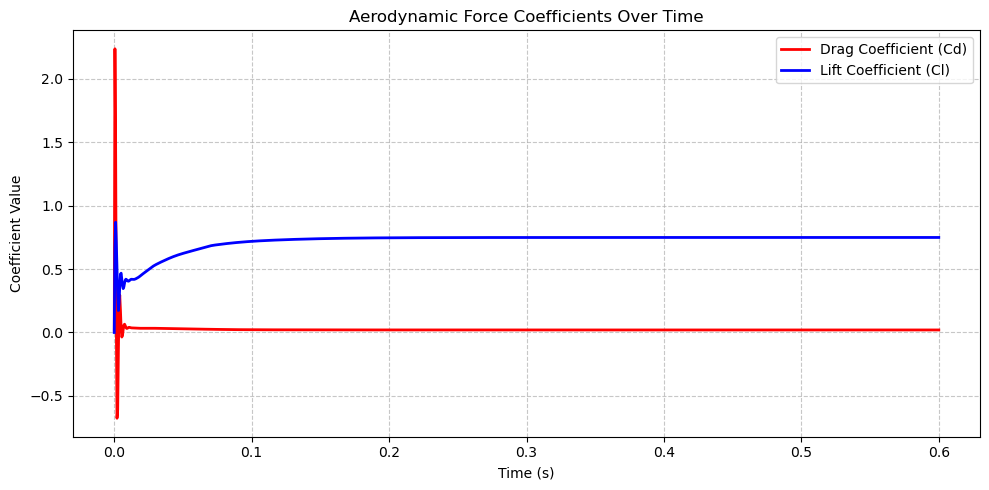

In [ ]:
forcecoeffs_file = "openfoam_naca/postProcessing/computeLiftDrag/0/forceCoeffs.dat"

# Read the space-delimited file, ignoring the OpenFOAM header lines starting with '#'
# Column 0 is Time, Column 1 is Cd, Column 3 is Cl
df = pd.read_csv(forcecoeffs_file, sep=r'\s+', comment='#', header=None)

# Extract columns
time = df[0]
cd = df[2]
cl = df[3]

plt.figure(figsize=(10, 5))
plt.plot(time, cd, label="Drag Coefficient (Cd)", color="red", linewidth=2)
plt.plot(time, cl, label="Lift Coefficient (Cl)", color="blue", linewidth=2)

plt.title("Aerodynamic Force Coefficients Over Time")
plt.xlabel("Time (s)")
plt.ylabel("Coefficient Value")
plt.grid(True, linestyle="--", alpha=0.7)
plt.legend()

plt.tight_layout()
# plt.savefig("force_coefficients_plot.png")
plt.show()

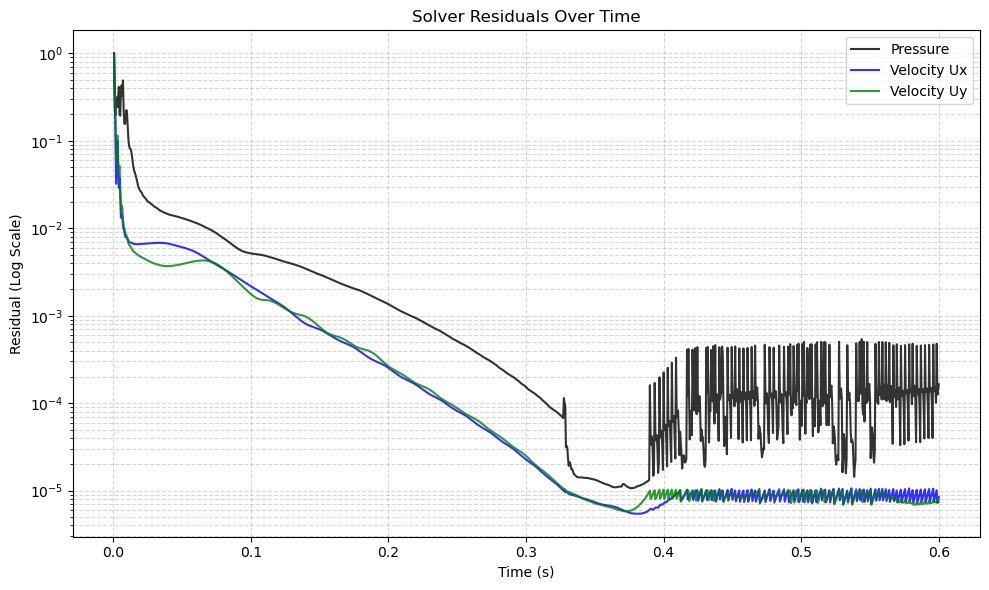

In [5]:
residuals_file = "openfoam_naca/postProcessing/residuals/0/residuals.dat"

# Read the data, ignoring headers and comments
df = pd.read_csv(residuals_file, sep=r'\s+', comment='#', header=None)

plt.figure(figsize=(10, 6))

time = df[0]
r_ux = df[1]
r_uy = df[2]
r_p = df[3]

plt.plot(time, r_p, label='Pressure', color='black', alpha=0.8)
plt.plot(time, r_ux, label='Velocity Ux', color='blue', alpha=0.8)
plt.plot(time, r_uy, label='Velocity Uy', color='green', alpha=0.8)

# Set the Y-axis to logarithmic to view convergence properly
plt.yscale('log')

plt.title("Solver Residuals Over Time")
plt.xlabel("Time (s)")
plt.ylabel("Residual (Log Scale)")
plt.grid(True, which="both", linestyle="--", alpha=0.5)
plt.legend()

plt.tight_layout()
# plt.savefig("residuals_plot.png")
plt.show()